<a href="https://colab.research.google.com/github/Gonza2000/used-car-market-prediction/blob/dev-daniel/IQR_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo del Mercado de Vehículos Usados mediante el Desarrollo de Modelos de Regresión y Técnicas Avanzadas de Ingeniería de Datos

**Materia:** Prácticas y herramientas de big data
**Institución:** UIDE (Powered by Arizona State University)

### Integrantes
* Daniel Cadena
* Gonzalo Cárdenas
* Gabriel Vasquez

---

## 1. Explicación del Proyecto
El presente proyecto integrador aplica el ciclo de vida de la ciencia de datos para construir un sistema predictivo capaz de estimar con alta precisión el valor comercial de vehículos usados. A diferencia de los vehículos nuevos, el valor de un automóvil de segunda mano está determinado por una interacción compleja y no lineal de múltiples factores, como el kilometraje, reputación de la marca y especificaciones.

---

## 2. Hipótesis del Proyecto

*(Formuladas antes del análisis exploratorio para evitar sesgo de confirmación)*

* **Hipótesis a demostrar:** Los métodos tradicionales de tasación manual omiten variables críticas de contexto y no logran correlacionar eficientemente variables de alta cardinalidad con variables continuas. Demostraremos que un algoritmo puede predecir el valor comercial con un error significativamente menor al de tablas estáticas.
* **Qué esperamos descubrir/predecir:** Esperamos aislar el impacto económico exacto que tienen factores como el kilometraje acumulado, la marca y la antigüedad en la depreciación del vehículo.
* **Relación con los datos:** El dataset masivo extraído contiene el registro histórico de precios junto con todas estas características. Al procesarlo, podremos encontrar los patrones ocultos (relación no lineal) que el ojo humano o una fórmula lineal estática no pueden procesar eficientemente.

## 3. Extracción de Datos

Para cumplir con el requerimiento de consumir una API pública, nos conectaremos a la **API oficial de Kaggle**. Esto nos permite autenticarnos e ingestar el conjunto de datos masivo de Craigslist directamente al entorno de Colab sin necesidad de descargas manuales.

* **API Pública consumida:** Kaggle REST API.
* **Dataset:** `austinreese/craigslist-carstrucks-data`
* **Método de extracción:** Mediante el cliente de línea de comandos de Kaggle y la librería `pandas` para estructurar la data en un DataFrame.

> **Nota de seguridad:** Las credenciales de Kaggle se leen desde los **Secrets de Google Colab** (o variables de entorno), nunca escritas directamente en el código. Para configurarlo, ir a: `Herramientas > Secrets` en Colab y agregar `KAGGLE_USERNAME` y `KAGGLE_KEY`.

In [ ]:
# ==========================================
# 3. EXTRACCIÓN DE DATOS MEDIANTE API
# ==========================================

import os
import pandas as pd

# 1. Instalamos la librería oficial de Kaggle
!pip install -q kaggle

# 2. Autenticación con tu Token de API Directo (Sin necesidad de subir archivos)
# Usamos el token exacto que generaste en Kaggle
os.environ['KAGGLE_API_TOKEN'] = "KGAT_a0fcdeed3125aab3d652c9bc808ee163"

# 3. Consumo de la API para descargar el dataset
print("Conectando con la API de Kaggle...")
print("Descargando y descomprimiendo el dataset masivo (esto puede tomar un par de minutos)...")
!kaggle datasets download -d austinreese/craigslist-carstrucks-data --unzip
print("¡Descarga completada con éxito!\n")

# 4. Carga de los datos extraídos
# Usamos low_memory=False para archivos grandes y on_bad_lines='skip' para ignorar filas corruptas
df = pd.read_csv('vehicles.csv', encoding='latin1', on_bad_lines='skip', low_memory=False)

# 5. Evidencia de variables obtenidas y cantidad de registros
print("--- EVIDENCIA DE EXTRACCIÓN ---")
print(f"Cantidad total de registros: {df.shape[0]}")
print(f"Cantidad total de variables (columnas): {df.shape[1]}")
print("\nVariables obtenidas:")
print(df.dtypes)

# Mostramos las primeras filas para confirmar que todo está en orden
df.head()

Conectando con la API de Kaggle...
Descargando y descomprimiendo el dataset masivo (esto puede tomar un par de minutos)...
Dataset URL: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
License(s): CC0-1.0
100% 262M/262M [00:01<00:00, 175MB/s]

¡Descarga completada con éxito!

--- EVIDENCIA DE EXTRACCIÓN ---
Cantidad total de registros: 426880
Cantidad total de variables (columnas): 26

Variables obtenidas:
id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county          float64
state            object
lat             

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


## 4. Limpieza y Preprocesamiento

En esta fase, diseñamos un pipeline exhaustivo de manipulación de datos. El objetivo es transformar los registros crudos del mercado en conocimiento estructurado y libre de ruido.

**Pasos ejecutados:**
1. **Eliminación de duplicados y columnas irrelevantes:** Columnas como `url`, `region_url`, `image_url`, `description`, `VIN` y `county` no aportan valor predictivo.
2. **Filtrado de precios con sentido comercial:** Se elimina cualquier vehículo con precio ≤ $500 o > $150,000 (límites basados en el mercado real de Craigslist para vehículos de uso privado).
3. **Saneamiento de odómetro:** Se eliminan lecturas físicamente imposibles (>500,000 millas). Los valores nulos de odómetro se **conservan deliberadamente** — serán imputados por la mediana dentro del pipeline de ML. Esta estrategia maximiza el volumen de datos útiles.
4. **Filtrado de años válidos:** Solo se conservan vehículos entre 1980 y el año actual. Los nulos de `year` también se conservan para que el imputador los maneje.
5. **Tratamiento de nulos:** La imputación ocurre dentro del pipeline de ML (`SimpleImputer`). En el EDA se descartan solo las filas donde `year` **y** `odometer` son ambos nulos simultáneamente (`how='all'`), ya que esos registros no contienen ningún predictor numérico útil.
6. **Reporte de impacto:** Se documenta cuántos registros se eliminan en cada paso.

In [ ]:
# ==========================================
# 4. LIMPIEZA Y PREPROCESAMIENTO
# ==========================================

import pandas as pd
import numpy as np

registros_inicial = df.shape[0]
print(f"Registros en bruto: {registros_inicial:,}")

# --- PASO 1: Eliminar duplicados ---
df_clean = df.drop_duplicates()
print(f"Tras eliminar duplicados:       {df_clean.shape[0]:,}  "
      f"(-{registros_inicial - df_clean.shape[0]:,})")

# --- PASO 2: Eliminar columnas que no aportan valor predictivo ---
cols_irrelevantes = ['id', 'url', 'region_url', 'image_url', 'description',
                     'VIN', 'county', 'posting_date', 'lat', 'long']
df_clean = df_clean.drop(columns=[c for c in cols_irrelevantes if c in df_clean.columns])
print(f"Columnas tras limpieza:         {df_clean.shape[1]} variables relevantes")

# --- PASO 3: Filtrado de precios con sentido comercial ---
#   Se usan límites absolutos basados en el mercado (no IQR, que en distribuciones
#   sesgadas elimina autos de lujo legítimos).
PRECIO_MIN = 500
PRECIO_MAX = 150_000
antes = df_clean.shape[0]
df_clean = df_clean[(df_clean['price'] > PRECIO_MIN) & (df_clean['price'] <= PRECIO_MAX)]
print(f"Tras filtro de precio (${PRECIO_MIN:,}–${PRECIO_MAX:,}): "
      f"{df_clean.shape[0]:,}  (-{antes - df_clean.shape[0]:,})")
print(f"  Precio mínimo resultante:  ${df_clean['price'].min():,.0f}")
print(f"  Precio máximo resultante:  ${df_clean['price'].max():,.0f}")
print(f"  Precio mediana:            ${df_clean['price'].median():,.0f}")

######################## DESCARTE DE MÉTODO IQR ##################
#Q1 = df_clean['price'].quantile(0.25)
#Q3 = df_clean['price'].quantile(0.75)
#IQR = Q3 - Q1
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
# Filtramos los precios que tienen sentido comercial (ej. eliminando autos a $1 o precios irreales)
#df_clean = df_clean[(df_clean['price'] >= lower_bound) & (df_clean['price'] <= upper_bound) & (df_clean['price'] > 500)]

# --- PASO 4: Filtrado de odómetro con valores válidos ---
ODOMETRO_MIN = 1
ODOMETRO_MAX = 500_000
antes = df_clean.shape[0]
df_clean = df_clean[
    df_clean['odometer'].isna() |
    ((df_clean['odometer'] >= ODOMETRO_MIN) & (df_clean['odometer'] <= ODOMETRO_MAX))
]
print(f"Tras filtro de odómetro (≤{ODOMETRO_MAX:,} mi): "
      f"{df_clean.shape[0]:,}  (-{antes - df_clean.shape[0]:,})")

# --- PASO 5: Filtrado de años válidos ---
import datetime
ANO_MIN = 1980
ANO_MAX = datetime.datetime.now().year + 1
antes = df_clean.shape[0]
df_clean = df_clean[
    df_clean['year'].isna() |
    ((df_clean['year'] >= ANO_MIN) & (df_clean['year'] <= ANO_MAX))
]
print(f"Tras filtro de año ({ANO_MIN}–{ANO_MAX}):  "
      f"{df_clean.shape[0]:,}  (-{antes - df_clean.shape[0]:,})")

# --- RESUMEN FINAL ---
print(f"\n--- DATASET LIMPIO ---")
print(f"Registros finales:    {df_clean.shape[0]:,}")
print(f"Variables:            {df_clean.shape[1]}")
print(f"Registros eliminados: {registros_inicial - df_clean.shape[0]:,} "
      f"({(registros_inicial - df_clean.shape[0])/registros_inicial*100:.1f}%)")

# --- REPORTE DE NULOS por variable ---
print("\n--- PORCENTAJE DE NULOS POR VARIABLE ---")
nulos = (df_clean.isnull().sum() / len(df_clean) * 100).round(1)
print(nulos[nulos > 0].sort_values(ascending=False).to_string())

Registros en bruto: 426,880
Tras eliminar duplicados:       426,880  (-0)
Columnas tras limpieza:         16 variables relevantes
Tras filtro de precio ($500–$150,000): 383,569  (-43,311)
  Precio mínimo resultante:  $501
  Precio máximo resultante:  $150,000
  Precio mediana:            $15,953
Tras filtro de odómetro (≤500,000 mi): 381,361  (-2,208)
Tras filtro de año (1980–2027):  373,818  (-7,543)

--- DATASET LIMPIO ---
Registros finales:    373,818
Variables:            16
Registros eliminados: 53,062 (12.4%)

--- PORCENTAJE DE NULOS POR VARIABLE ---
size            72.1
cylinders       40.9
condition       38.0
drive           30.1
paint_color     28.6
type            20.9
manufacturer     3.5
title_status     1.8
model            1.0
fuel             0.7
odometer         0.6
transmission     0.5
year             0.3


## 5. Análisis Exploratorio de Datos (EDA)

Antes de construir el modelo, exploramos visualmente el dataset para:
- Verificar la distribución de la variable objetivo (`price`)
- Entender la relación entre el kilometraje y el precio
- Analizar el impacto del año de fabricación
- Identificar las marcas más frecuentes en el mercado

También verificamos si una transformación logarítmica del precio mejora la distribución para el modelo de regresión.

Registros para EDA y modelado: 373,756

--- ESTADÍSTICAS DESCRIPTIVAS (variables numéricas) ---
           price       year   odometer
count  373756.00  372658.00  371720.00
mean    19359.52    2012.00   93880.66
std     14746.72       6.39   64227.07
min       501.00    1980.00       1.00
25%      7900.00    2008.00   39063.50
50%     15990.00    2013.00   88727.00
75%     27990.00    2017.00  136897.50
max    150000.00    2022.00  500000.00


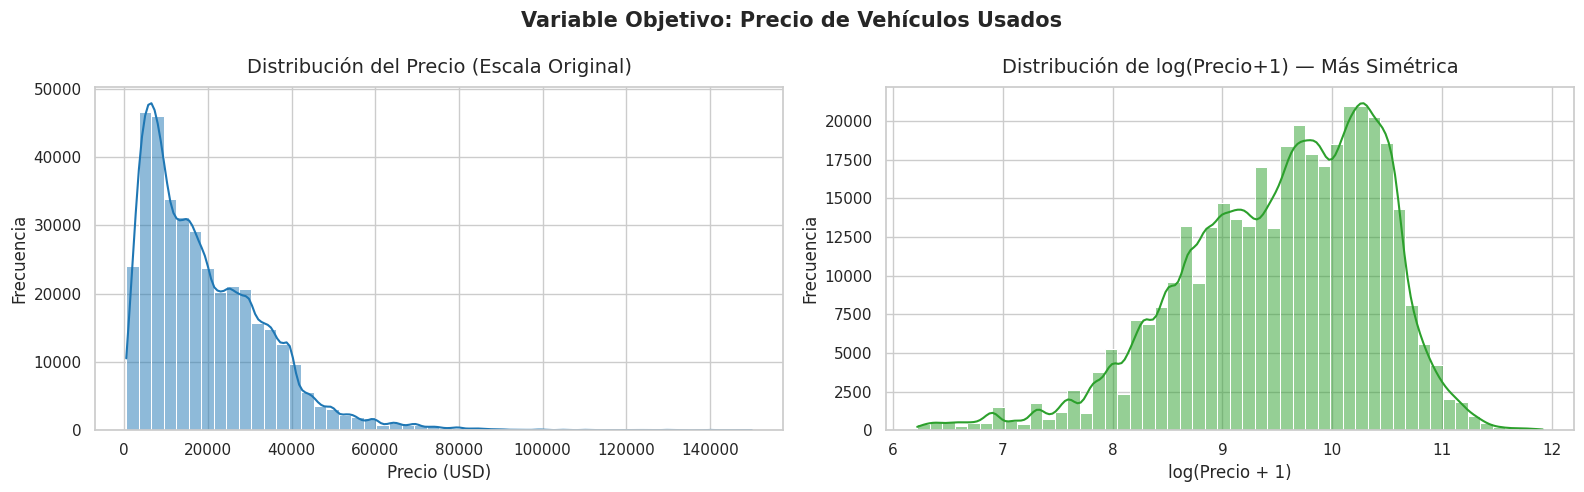

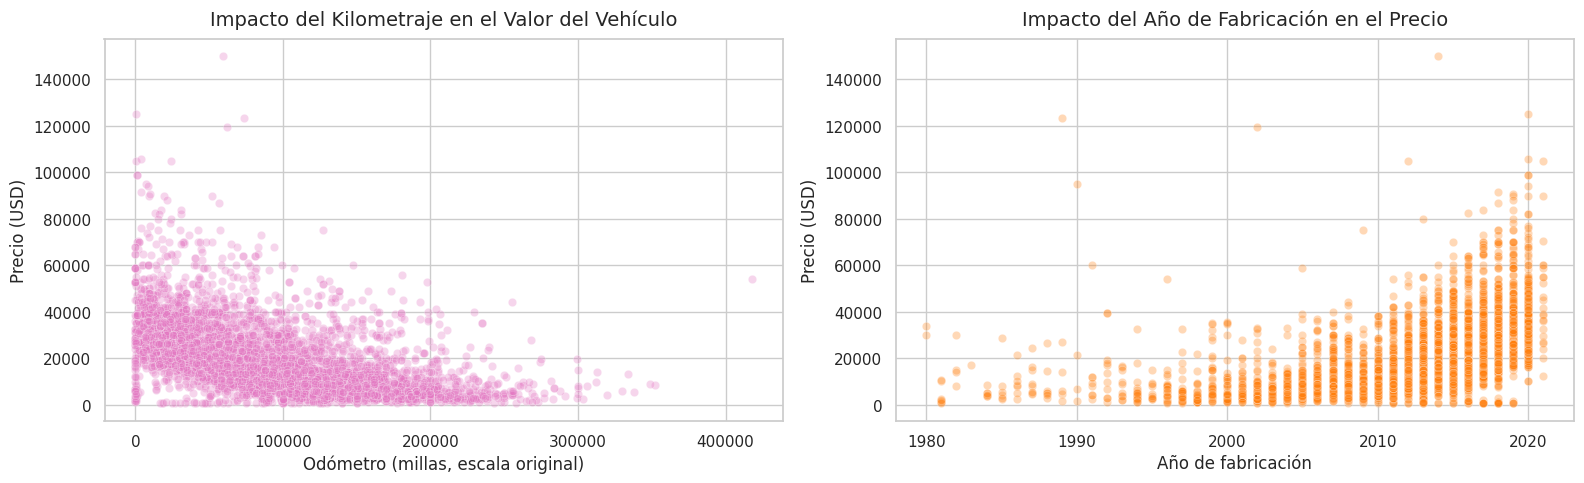

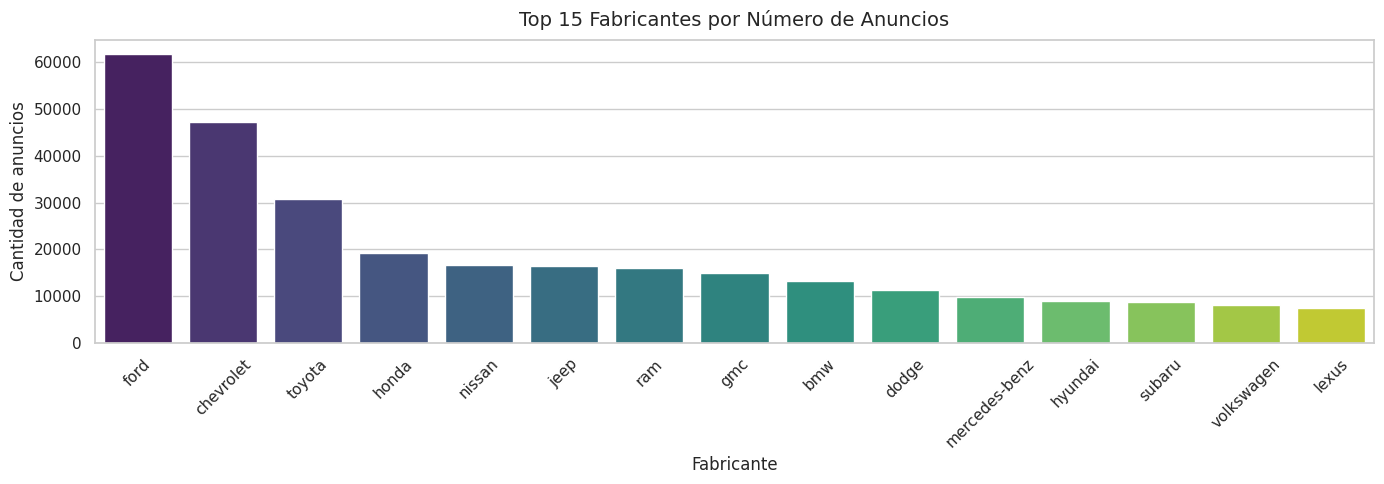


X shape: (373756, 14)  |  y shape: (373756,)


In [ ]:
# =======================================================
# 5. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# =======================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selección de variables predictoras relevantes
variables_reales = [
    'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders',
    'fuel', 'odometer', 'title_status', 'transmission', 'drive',
    'size', 'type', 'paint_color', 'state'
]
# how='all': se eliminan SOLO las filas donde year Y odometer son ambos nulos
# simultáneamente. Las filas con solo odometer=NaN son útiles: el SimpleImputer
# las rellenará con la mediana de entrenamiento. Igual para year=NaN en solitario.
# Solo se descartan registros sin NINGÚN predictor numérico clave, maximizando datos.
df_analisis = df_clean[variables_reales].dropna(subset=['year', 'odometer'], how='all')

print(f"Registros para EDA y modelado: {df_analisis.shape[0]:,}")
print("\n--- ESTADÍSTICAS DESCRIPTIVAS (variables numéricas) ---")
print(df_analisis[['price', 'year', 'odometer']].describe().round(2).to_string())

# =============================================================
# GRÁFICOS EDA
# =============================================================
sns.set_theme(style="whitegrid")

# --- Fila 1: Distribución de precio (original vs log) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1a: Precio original
sns.histplot(df_analisis['price'], bins=50, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribución del Precio (Escala Original)', fontsize=14, pad=10)
axes[0].set_xlabel('Precio (USD)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# Gráfico 1b: log(Precio) — verificación de normalidad
sns.histplot(np.log1p(df_analisis['price']), bins=50, kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Distribución de log(Precio+1) — Más Simétrica', fontsize=14, pad=10)
axes[1].set_xlabel('log(Precio + 1)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.suptitle('Variable Objetivo: Precio de Vehículos Usados', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Fila 2: Odómetro vs Precio, y Año vs Precio ---
df_sample = df_analisis.dropna(subset=['odometer', 'year']).sample(
    n=min(5000, len(df_analisis.dropna(subset=['odometer','year']))),
    random_state=42
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 2a: Kilometraje vs Precio
sns.scatterplot(data=df_sample, x='odometer', y='price', alpha=0.3, ax=axes[0], color='#e377c2')
axes[0].set_title('Impacto del Kilometraje en el Valor del Vehículo', fontsize=14, pad=10)
axes[0].set_xlabel('Odómetro (millas, escala original)', fontsize=12)
axes[0].set_ylabel('Precio (USD)', fontsize=12)

# Gráfico 2b: Año vs Precio
sns.scatterplot(data=df_sample, x='year', y='price', alpha=0.3, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Impacto del Año de Fabricación en el Precio', fontsize=14, pad=10)
axes[1].set_xlabel('Año de fabricación', fontsize=12)
axes[1].set_ylabel('Precio (USD)', fontsize=12)

plt.tight_layout()
plt.show()

# --- Gráfico 3: Top 15 Fabricantes más frecuentes ---
fig, ax = plt.subplots(figsize=(14, 5))
top_makers = df_analisis['manufacturer'].value_counts().head(15)
sns.barplot(x=top_makers.index, y=top_makers.values, hue=top_makers.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Top 15 Fabricantes por Número de Anuncios', fontsize=14, pad=10)
ax.set_xlabel('Fabricante', fontsize=12)
ax.set_ylabel('Cantidad de anuncios', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# --- Definición de X e y para el pipeline de modelado ---
X = df_analisis.drop('price', axis=1)
y = df_analisis['price']
print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")

## 6. Modelos Seleccionados

Para evaluar el rendimiento analítico, entrenaremos múltiples arquitecturas de regresión. Al tratarse de una predicción de precio (una variable continua), el problema a resolver es estrictamente de regresión.

1. **Regresión Lineal Múltiple:**
   * *Justificación Técnica:* Servirá como nuestro modelo base (baseline). Permite entender de manera muy interpretable cómo cada variable independiente afecta linealmente al precio.
   
2. **Regresión Ridge / Lasso:**
   * *Justificación Técnica:* Dado que tenemos variables de alta cardinalidad, los modelos de regularización (Ridge/Lasso) ayudarán a penalizar características irrelevantes, reduciendo el riesgo de sobreajuste (overfitting).

3. **Ensambles basados en Árboles (XGBoost / Gradient Boosting):**
   * *Justificación Técnica:* Son los algoritmos más robustos para datos tabulares masivos. Pueden modelar las interacciones complejas y no lineales del mercado (como la relación conjunta entre marca, año y kilometraje) y son los mejores candidatos para reducir el error absoluto medio (MAE).